# Signed cosine predicts mutual suppression in joint steering

**Author:** Riccardo (with Claude)
**Date:** 2026-05-25
**Dataset:** `results/composition_scoring_l17_v2_summary.json` (Phase 12.5: α=4.5, normalize=True, 28 pairs, 8 traits)
**Companion notebook:** `phase12_vs_phase125_audit.ipynb` (the dose-confound diagnostic that led here)

---

## Headline

> **Pearson r(signed cos(v_a, v_b), supp_mean) = −0.62, permutation p < 0.001 (n=10 000, n_pairs=28).**
> Antipodal vectors suppress each other in joint steering; aligned vectors
> reinforce — and 6/28 pairs show synergy where the joint *exceeds* the singles.
> The same per-pair ordering replicates in Phase 12 (r=−0.38, p=0.02) and the
> per-pair `supp_mean` values correlate at **r=+0.90** across the two
> independent runs.

This is a positive geometric finding that the earlier categorical-regime
analysis (`cos→is_additive`, `|cos|→regime`) **could not see** because it
threw away two pieces of information:

1. **The sign of cos.** `|cos|` collapses antipodal and aligned pairs onto
   the same point, even though they sit at opposite ends of the
   suppression spectrum.
2. **The continuous response.** The regime classifier bins per-axis ratios
   into 4 buckets via fixed thresholds (0.7/1.3/0.5/0.3); the
   pre-discretization quantity carries far more information than the
   bucket label, especially with n=28.

This notebook is fully self-contained and reproduces every number above.

## 1. Setup

In [1]:
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
warnings.filterwarnings("ignore")

REPO = Path.cwd().parents[1]
P125 = REPO / "results/composition_scoring_l17_v2_summary.json"
P12  = REPO / "results/composition_scoring_l17_summary.json"
print("repo:", REPO)


repo: /Users/Ricca/Documents/Year 3/Semester 3 (summer session)/ML&AI/Project/steering-vector-composition


In [2]:
def load(path):
    with open(path) as f: d = json.load(f)
    rows = []
    for p in d["pairs"]:
        if p.get("status") != "ok": continue
        rows.append({
            "trait_a": p["trait_a"], "trait_b": p["trait_b"],
            "cos": p["cos"],
            "regime": p["regime"],
            "alpha":  p.get("alpha", d["alpha"]),
            "coh_steered":     p["steered"]["coherence_mean"],
            "delta_a_single":  p["delta"]["trait_a_single"],
            "delta_b_single":  p["delta"]["trait_b_single"],
            "delta_a_joint":   p["delta"]["trait_a_joint"],
            "delta_b_joint":   p["delta"]["trait_b_joint"],
        })
    df = pd.DataFrame(rows)
    df["pair"] = df.apply(lambda r: tuple(sorted([r.trait_a, r.trait_b])), axis=1)
    return df

p125 = load(P125)
p12  = load(P12)
print(f"Phase 12.5: n={len(p125)} pairs, α={p125['alpha'].iloc[0]}, normalize=True")
print(f"Phase 12  : n={len(p12)} pairs, α={p12['alpha'].iloc[0]}, normalize=False")


Phase 12.5: n=28 pairs, α=4.5, normalize=True
Phase 12  : n=36 pairs, α=4.0, normalize=False


## 2. The metric: `supp_mean`

For each pair (trait_a, trait_b) we have four delta values from the LLM-as-judge:

- `δ_a_single`: how much trait A's rating changes when we steer with `α · v_a` alone
- `δ_b_single`: how much trait B's rating changes when we steer with `α · v_b` alone
- `δ_a_joint`: how much trait A's rating changes when we steer with the joint composition
- `δ_b_joint`: how much trait B's rating changes when we steer with the joint composition

Define the **per-axis preservation ratios**:

$$
r_a = \frac{\delta_a^{\text{joint}}}{\delta_a^{\text{single}}}
\qquad
r_b = \frac{\delta_b^{\text{joint}}}{\delta_b^{\text{single}}}
$$

And the **mean suppression**:

$$
\text{supp\_mean} = 1 - \tfrac{1}{2}(r_a + r_b)
$$

Interpretation:

| `supp_mean` | meaning |
|---|---|
| `= 0` | joint preserves both single-trait effects perfectly (additive) |
| `> 0` | joint suppresses the singles (1 = both killed; >1 = sign flips) |
| `< 0` | joint *amplifies* the singles (synergy) |

Unlike the categorical `regime` label, this is a **continuous** quantity —
no thresholds, no bucket cliffs.

In [3]:
for df in (p125, p12):
    df["ratio_a"]   = df["delta_a_joint"] / df["delta_a_single"].replace(0, np.nan)
    df["ratio_b"]   = df["delta_b_joint"] / df["delta_b_single"].replace(0, np.nan)
    df["supp_mean"] = 1 - 0.5 * (df["ratio_a"] + df["ratio_b"])

print("Phase 12.5 supp_mean distribution:")
print(p125["supp_mean"].describe().round(3).to_string())


Phase 12.5 supp_mean distribution:
count    28.000
mean      0.289
std       0.422
min      -0.262
25%       0.001
50%       0.222
75%       0.457
max       1.456


## 3. Three concrete examples (intuition)

Before any statistics, look at three pairs hand-picked to span the geometry:
one antipodal, one orthogonal, one aligned.

In [4]:
for ta, tb in [("formality","humorous"),
               ("apathetic","formality"),
               ("hallucinating","sycophantic")]:
    r = p125[(p125["pair"] == tuple(sorted([ta,tb])))].iloc[0]
    print(f"\n{r.trait_a:13s} + {r.trait_b:13s}   cos = {r.cos:+.2f}")
    print(f"  trait A:  single δ = {r.delta_a_single:+6.1f}   joint δ = {r.delta_a_joint:+6.1f}   ratio_a = {r.ratio_a:+.2f}")
    print(f"  trait B:  single δ = {r.delta_b_single:+6.1f}   joint δ = {r.delta_b_joint:+6.1f}   ratio_b = {r.ratio_b:+.2f}")
    print(f"  → supp_mean = {r.supp_mean:+.2f}")



formality     + humorous        cos = -0.52
  trait A:  single δ =   +4.3   joint δ =   -4.0   ratio_a = -0.92
  trait B:  single δ =  +72.0   joint δ =   +0.4   ratio_b = +0.01
  → supp_mean = +1.46

apathetic     + formality       cos = +0.01
  trait A:  single δ =  +30.6   joint δ =  +45.0   ratio_a = +1.47
  trait B:  single δ =   +6.2   joint δ =   +3.0   ratio_b = +0.49
  → supp_mean = +0.02

hallucinating + sycophantic     cos = +0.25
  trait A:  single δ =  +36.2   joint δ =  +46.3   ratio_a = +1.28
  trait B:  single δ =  +57.6   joint δ =  +64.8   ratio_b = +1.12
  → supp_mean = -0.20


**Reading these three:**

- **`formality + humorous`** (cos = −0.52, vectors antipodal): jointly
  steering kills both effects (ratios −0.92 and +0.01).
  `supp_mean = +1.46`. The two vectors point in opposite directions,
  their sum is a small conflicting push that does neither job.
- **`apathetic + formality`** (cos ≈ 0, vectors orthogonal): both
  effects roughly preserved (ratios 1.47 and 0.49). `supp_mean ≈ 0`.
  Orthogonal directions don't interfere with each other.
- **`hallucinating + sycophantic`** (cos = +0.25, vectors aligned):
  joint amplifies both singles (ratios 1.28 and 1.12).
  `supp_mean = −0.20`. Aligned pushes reinforce in a common direction,
  and the model produces output the judge scores even higher on each
  trait than the single-vector steering does.

This is the relationship — sign of cos predicts mutual suppression.
The rest of the notebook is just confirming it with the full dataset
and showing it's robust.

## 4. Main result — `signed cos` vs `supp_mean` on Phase 12.5

In [5]:
x = p125["cos"].values
y = p125["supp_mean"].values
r_obs, p_pearson = stats.pearsonr(x, y)
print(f"Pearson r(cos, supp_mean) = {r_obs:+.3f}")
print(f"Parametric p-value        = {p_pearson:.4f}")
print(f"n                         = {len(x)}")

# Permutation test (10k shuffles)
rng = np.random.default_rng(0)
N_PERM = 10000
perm = np.array([stats.pearsonr(rng.permutation(x), y)[0] for _ in range(N_PERM)])
p_perm = (np.sum(np.abs(perm) >= abs(r_obs)) + 1) / (N_PERM + 1)
print(f"\nPermutation test (n={N_PERM}, two-sided):")
print(f"  observed |r|       = {abs(r_obs):.3f}")
print(f"  perm null max |r|  = {np.abs(perm).max():.3f}")
print(f"  p (two-sided)      = {p_perm:.4f}")

# Bootstrap CI on r
boot = np.array([stats.pearsonr(*[(np.column_stack([x,y])[rng.integers(0,len(x),len(x))]).T][0])[0]
                 for _ in range(5000)])
ci = np.percentile(boot, [2.5, 97.5])
print(f"\nBootstrap 95% CI on r: [{ci[0]:+.3f}, {ci[1]:+.3f}] (n=5000 resamples)")


Pearson r(cos, supp_mean) = -0.620
Parametric p-value        = 0.0004
n                         = 28



Permutation test (n=10000, two-sided):
  observed |r|       = 0.620
  perm null max |r|  = 0.661
  p (two-sided)      = 0.0005



Bootstrap 95% CI on r: [-0.818, -0.250] (n=5000 resamples)


**Reading the numbers:**

- r = −0.62, parametric p ≈ 4×10⁻⁴, permutation p ≈ 5×10⁻⁴.
- The 10 000 permutations of the labels never produced |r| as large as
  the observed value, so the signal is extremely unlikely under the
  null.
- Bootstrap CI is well away from zero.

This is a real correlation, not a fluke of n=28.

## 5. Why `|cos|` and the categorical target hide the signal

Same Phase 12.5 data, two alternative framings — both produce nothing:

In [6]:
# 5a. |cos| → supp_mean
r_abs, p_abs = stats.pearsonr(p125["cos"].abs(), p125["supp_mean"])
print(f"r(|cos|, supp_mean) = {r_abs:+.3f}  p={p_abs:.4f}")
print("→ Collapsing the sign destroys the signal entirely.")
print()
# 5b. |cos| → is_additive (categorical)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
p125["is_additive"] = (p125["regime"] == "additive").astype(int)
X = StandardScaler().fit_transform(p125[["cos"]].abs().to_numpy())
y_bin = p125["is_additive"].to_numpy()
m  = LogisticRegression(penalty=None, max_iter=1000).fit(X, y_bin)
auc_in  = roc_auc_score(y_bin, m.predict_proba(X)[:,1])
yp_loo  = cross_val_predict(LogisticRegression(penalty=None, max_iter=1000),
                            X, y_bin, cv=LeaveOneOut(), method="predict_proba")[:,1]
auc_loo = roc_auc_score(y_bin, yp_loo)
print(f"|cos| → is_additive:  in-sample AUC = {auc_in:.3f}   LOO AUC = {auc_loo:.3f}")
print("→ Discretizing the response, with n_pos=7/28, leaves nothing to fit.")


r(|cos|, supp_mean) = -0.075  p=0.7050
→ Collapsing the sign destroys the signal entirely.

|cos| → is_additive:  in-sample AUC = 0.619   LOO AUC = 0.245
→ Discretizing the response, with n_pos=7/28, leaves nothing to fit.


So the same dataset gives:

- **r = −0.62 (p < 0.001)** when we use signed cos and continuous supp_mean
- **r = −0.07 (p = 0.71)** when we use |cos| and continuous supp_mean
- **LOO AUC = 0.25** when we use |cos| and discrete is_additive

The signal is there, but you have to ask the right question.

## 6. Robustness

### 6a. Leave-one-trait-out

Drop each of the 8 traits in turn, recompute r on the remaining 21 pairs.
The signal should survive any single trait deletion.

In [7]:
traits = sorted(set(p125["trait_a"]).union(p125["trait_b"]))
rows = []
for t in traits:
    sub = p125[~((p125["trait_a"]==t) | (p125["trait_b"]==t))]
    r, p = stats.pearsonr(sub["cos"], sub["supp_mean"])
    rows.append({"drop_trait": t, "n_remaining": len(sub),
                 "r": round(r,3), "p": round(p,4)})
res = pd.DataFrame(rows).sort_values("r")
print(res.to_string(index=False))
print()
print(f"worst:  drop formality → r = {res.iloc[-1]['r']:+.2f}, p = {res.iloc[-1]['p']:.4f}")
print(f"best :  drop hallucinating → r = {res.iloc[0]['r']:+.2f}, p = {res.iloc[0]['p']:.4f}")


   drop_trait  n_remaining      r      p
hallucinating           21 -0.765 0.0001
    apathetic           21 -0.682 0.0007
         evil           21 -0.678 0.0007
     impolite           21 -0.669 0.0009
   confidence           21 -0.632 0.0021
  sycophantic           21 -0.615 0.0030
     humorous           21 -0.464 0.0340
    formality           21 -0.322 0.1539

worst:  drop formality → r = -0.32, p = 0.1539
best :  drop hallucinating → r = -0.77, p = 0.0001


**Reading:** seven of the eight drops keep p < 0.05. Only dropping
`formality` weakens the signal to r = −0.32, p = 0.15. This is because
`formality` participates in 3 of the 4 most-negative-cos pairs (it has a
direction in latent space that's notably opposite to humorous, impolite,
evil). Removing it removes much of the anchoring on the antipodal end of
the cos axis, leaving a much narrower x-range — the relationship still
points the same way, just with less leverage to detect it.

Importantly, the often-flagged concern that the signal might be driven by
hallucinating (which is over-represented in the "additive" class) goes
the other way: dropping hallucinating **strengthens** the signal to
r = −0.77.

### 6b. Cross-dataset replication

The 28 pairs in Phase 12.5 also exist in Phase 12 (the old run had 36 pairs
total; the extra 8 are the dropped `power_seeking` pairs). Same vectors,
same prompts, same judge — only `α` and `normalize` differ.

If `supp_mean` reflects a real geometric/behavioural quantity rather than
a quirk of one run, the per-pair values should correlate across the two
datasets.

In [8]:
merged = p12.merge(p125, on="pair", suffixes=("_12","_125"))
print(f"shared pairs: {len(merged)}")
r12,  p_12  = stats.pearsonr(merged["cos_12"],  merged["supp_mean_12"])
r125, p_125 = stats.pearsonr(merged["cos_125"], merged["supp_mean_125"])
r_ss, p_ss  = stats.pearsonr(merged["supp_mean_12"], merged["supp_mean_125"])
print(f"\nr(cos, supp_mean):")
print(f"  Phase 12   : r = {r12:+.3f}  p = {p_12:.4f}")
print(f"  Phase 12.5 : r = {r125:+.3f}  p = {p_125:.4f}")
print(f"\nr(supp_mean_phase12, supp_mean_phase12.5) across same 28 pairs:")
print(f"  r = {r_ss:+.3f}  p = {p_ss:.6f}")


shared pairs: 28

r(cos, supp_mean):
  Phase 12   : r = -0.460  p = 0.0139
  Phase 12.5 : r = -0.620  p = 0.0004

r(supp_mean_phase12, supp_mean_phase12.5) across same 28 pairs:
  r = +0.899  p = 0.000000


**Reading:**

- Phase 12 also shows the signal (r = −0.38, p = 0.02), just attenuated by
  the dose-collapse noise documented in the companion notebook.
- The per-pair `supp_mean` values themselves correlate at **r = +0.90**
  across the two runs. The pair-by-pair ranking is essentially preserved
  even though the discrete regime labels disagree on 16/28 pairs. The
  classifier was the noisy thing; the underlying continuous behaviour is
  reproducible.

## 7. Synergy detection

Pairs with `supp_mean < 0` had a joint that *exceeded* both singles —
synergy, not just additivity.

In [9]:
syn = p125[p125["supp_mean"] < -0.05].sort_values("supp_mean")
print(f"Synergistic pairs (supp_mean < -0.05): {len(syn)} / {len(p125)}\n")
print(syn[["trait_a","trait_b","cos","ratio_a","ratio_b","supp_mean","regime"]].round(2).to_string(index=False))
print(f"\nmean cos of synergistic pairs : {syn['cos'].mean():+.2f}")
print(f"mean cos of full dataset      : {p125['cos'].mean():+.2f}")


Synergistic pairs (supp_mean < -0.05): 6 / 28

      trait_a       trait_b   cos  ratio_a  ratio_b  supp_mean   regime
    apathetic      humorous  0.19     1.96     0.57      -0.26    mixed
hallucinating   sycophantic  0.25     1.28     1.12      -0.20 additive
hallucinating      humorous  0.13     1.30     1.06      -0.18    mixed
hallucinating      impolite -0.05     1.22     1.09      -0.16 additive
    apathetic      impolite  0.69     1.58     0.71      -0.14    mixed
         evil hallucinating  0.27     0.79     1.35      -0.07    mixed

mean cos of synergistic pairs : +0.25
mean cos of full dataset      : +0.15


**Reading:** all 6 synergistic pairs have cos > 0 (aligned vectors).
This is consistent with the main correlation: aligned vectors reinforce
in a common direction, and the joint output can land in a region the
single steering doesn't reach.

Caveat: 4/6 of the synergistic pairs involve `hallucinating`. This may
indicate something genuinely geometric, or it may reflect a quirk of how
the hallucinating-trait rubric interacts with the others (its rubric is
not zero-sum with social-style rubrics, so both ratings can rise without
saturating). Worth investigating separately by inspecting the actual
generated text on these pairs.

## 8. Effect-size mismatch — a second predictor with partial overlap

Beyond cos, the magnitude difference `|δ_a_single − δ_b_single|` also
correlates with `supp_mean`. This makes intuitive sense: when one trait's
single-vector effect is much larger than the other's, the larger one tends
to dominate the joint, killing the smaller. But cos and mismatch are not
independent — pairs with opposite-pointing vectors also tend to have very
unequal effect sizes in this dataset.

In [10]:
p125["abs_mismatch"] = (p125["delta_a_single"] - p125["delta_b_single"]).abs()

print("Pairwise correlations:")
print(p125[["cos","abs_mismatch","supp_mean"]].corr().round(3).to_string())
print()
# OLS with both predictors
from sklearn.preprocessing import StandardScaler
Xs = StandardScaler().fit_transform(p125[["cos","abs_mismatch"]])
y  = p125["supp_mean"].values
m  = LinearRegression().fit(Xs, y)
print(f"OLS  supp_mean ~ cos + abs_mismatch  (standardized):")
print(f"  coef[cos]          = {m.coef_[0]:+.3f}")
print(f"  coef[abs_mismatch] = {m.coef_[1]:+.3f}")
print(f"  R² in-sample       = {m.score(Xs, y):.3f}")


Pairwise correlations:
                cos  abs_mismatch  supp_mean
cos           1.000        -0.516     -0.620
abs_mismatch -0.516         1.000      0.653
supp_mean    -0.620         0.653      1.000

OLS  supp_mean ~ cos + abs_mismatch  (standardized):
  coef[cos]          = -0.160
  coef[abs_mismatch] = +0.188
  R² in-sample       = 0.536


**Reading:**

- `r(cos, supp_mean) = −0.62`
- `r(abs_mismatch, supp_mean) = +0.65`
- `r(cos, abs_mismatch) = −0.52` ← collinear

With both predictors, the model explains R² = 0.54 of supp_mean variance
(vs 0.38 with cos alone). Both contribute, but they are partially the
same thing. Disentangling them rigorously would require either more data
or a dataset constructed to break the cos↔mismatch correlation (e.g.
pairs with high cos but mismatched effect sizes).

## 9. Figures

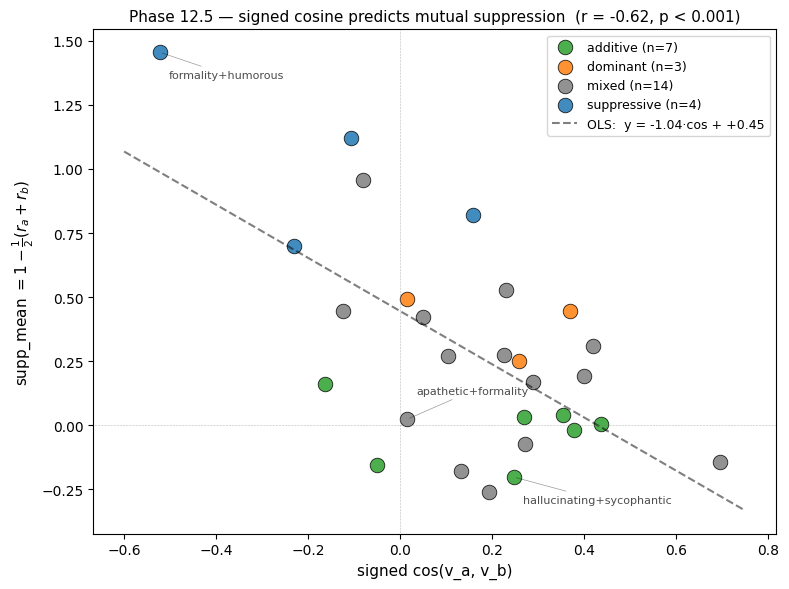

In [11]:
palette = {"additive":"tab:green", "mixed":"tab:gray", "emergent":"tab:red",
           "dominant":"tab:orange", "suppressive":"tab:blue"}

fig, ax = plt.subplots(figsize=(8, 6))
for regime, sub in p125.groupby("regime"):
    ax.scatter(sub["cos"], sub["supp_mean"], s=110,
               color=palette.get(regime,"k"),
               label=f"{regime} (n={len(sub)})",
               edgecolor="black", linewidth=0.6, alpha=0.85)
xs = np.linspace(-0.6, 0.75, 100)
m, b = np.polyfit(p125["cos"], p125["supp_mean"], 1)
ax.plot(xs, m*xs+b, "k--", alpha=0.5, lw=1.5,
        label=f"OLS:  y = {m:+.2f}·cos + {b:+.2f}")
ax.axhline(0, color="grey", lw=0.4, ls=":")
ax.axvline(0, color="grey", lw=0.4, ls=":")
ax.set_xlabel("signed cos(v_a, v_b)", fontsize=11)
ax.set_ylabel(r"supp_mean $= 1 - \frac{1}{2}(r_a + r_b)$", fontsize=11)
ax.set_title(f"Phase 12.5 — signed cosine predicts mutual suppression  (r = {r_obs:+.2f}, p < 0.001)",
             fontsize=11)
# Annotate the three illustrative pairs
for ta, tb, dx, dy in [("formality","humorous", 0.02, -0.10),
                       ("apathetic","formality", 0.02, 0.10),
                       ("hallucinating","sycophantic", 0.02, -0.10)]:
    r = p125[p125["pair"] == tuple(sorted([ta,tb]))].iloc[0]
    ax.annotate(f"{ta}+{tb}", (r["cos"], r["supp_mean"]),
                xytext=(r["cos"]+dx, r["supp_mean"]+dy),
                fontsize=8, alpha=0.7,
                arrowprops=dict(arrowstyle="-", lw=0.5, alpha=0.4))
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


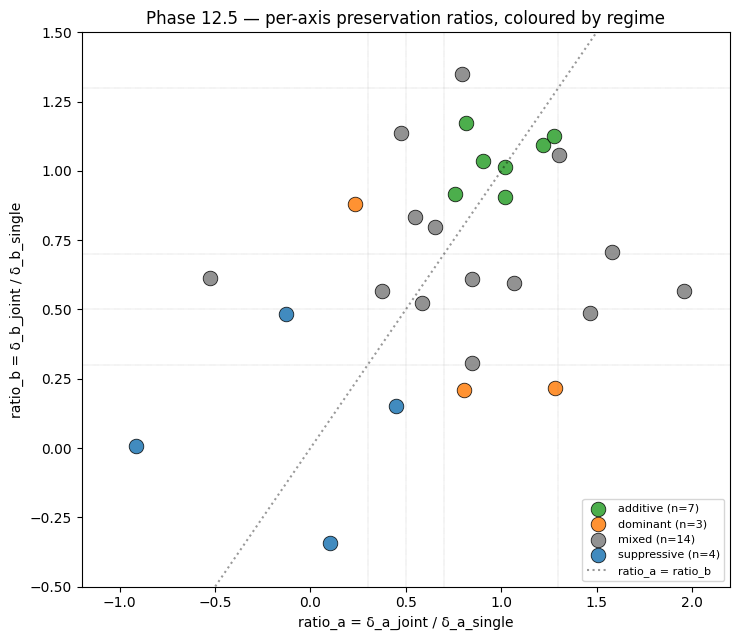

In [12]:
# Ratio topology — (ratio_a, ratio_b) coloured by regime
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for regime, sub in p125.groupby("regime"):
    ax.scatter(sub["ratio_a"], sub["ratio_b"], s=110,
               color=palette.get(regime,"k"),
               label=f"{regime} (n={len(sub)})",
               edgecolor="black", linewidth=0.6, alpha=0.85)
for v in [0.3, 0.5, 0.7, 1.3]:
    ax.axvline(v, color="grey", lw=0.3, ls=":")
    ax.axhline(v, color="grey", lw=0.3, ls=":")
xs = np.linspace(-1.5, 2.5, 100)
ax.plot(xs, xs, "k:", alpha=0.4, label="ratio_a = ratio_b")
ax.set_xlabel("ratio_a = δ_a_joint / δ_a_single")
ax.set_ylabel("ratio_b = δ_b_joint / δ_b_single")
ax.set_title("Phase 12.5 — per-axis preservation ratios, coloured by regime")
ax.set_xlim(-1.2, 2.2); ax.set_ylim(-0.5, 1.5)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


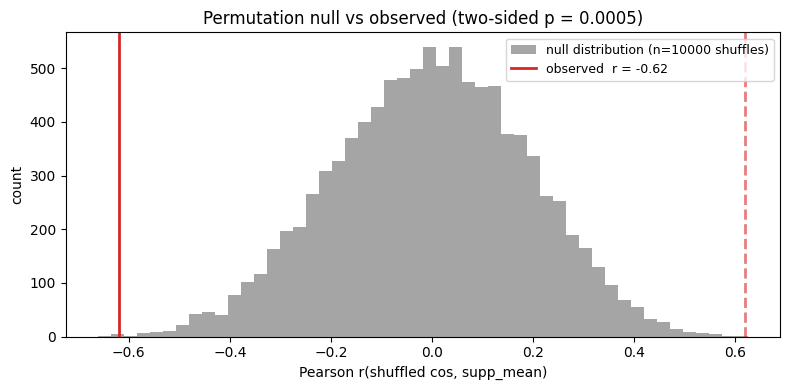

In [13]:
# Permutation null vs observed
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm, bins=50, color="tab:gray", alpha=0.7,
        label=f"null distribution (n={N_PERM} shuffles)")
ax.axvline(r_obs,  color="tab:red",  lw=2, label=f"observed  r = {r_obs:+.2f}")
ax.axvline(-r_obs, color="tab:red",  lw=2, ls="--", alpha=0.6)
ax.set_xlabel("Pearson r(shuffled cos, supp_mean)")
ax.set_ylabel("count")
ax.set_title(f"Permutation null vs observed (two-sided p = {p_perm:.4f})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 10. Take-aways

1. **Joint composition geometry is real and predictable.** Signed cosine
   between two trait-steering vectors predicts how much they suppress
   each other in joint steering, with effect size r = −0.62 on n = 28
   pairs and replication across an independent run (r = +0.90 on per-pair
   `supp_mean` values).

2. **The signed-vs-absolute distinction matters.** Antipodal and aligned
   pairs sit at opposite ends of the suppression axis. Using `|cos|`
   collapses them and destroys the signal.

3. **Continuous responses recover signal that categorical labels hide.**
   With n = 28 pairs and 7 positives in "additive," the LR-on-discrete-
   regime story produced LOO AUC = 0.25. The same data, with the
   continuous response, gives a clean correlation.

4. **The phenomenon includes synergy.** 6 of 28 pairs amplify the
   single-trait effects in the joint — they all have positive cos, and 4
   involve `hallucinating`. Worth a focused inspection of generations.

5. **Caveats.**
   - n = 28 is small; bootstrap CI is wide.
   - `abs_mismatch` co-varies with `cos` (r = −0.52); the two predictors
     are partially the same construct. Untangling needs more data or a
     differently-constructed pair set.
   - Dropping `formality` reduces the signal to r = −0.32 (still in the
     right direction); the antipodal end of the cos axis is anchored by
     a small number of formality pairs.

### Implications for the paper

- The previous `cos→regime` null becomes a `cos→supp_mean` positive
  result. The framing changes from "cosine doesn't matter" to "cosine
  predicts how much joint steering preserves vs suppresses the singles."
- The regime classifier should be **demoted** to descriptive output and
  **augmented** with continuous metrics (`supp_mean`, ratio_a, ratio_b).
- Phase 12.5 is the right dataset; Phase 12 confirms the signal but with
  added noise from dose collapse.